## **Laboratorio 05**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

In [2]:
# Cargar datos
df = pd.read_csv('https://raw.githubusercontent.com/fralfaro/MAT281/main/docs/labs/data/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


**Parte 1. Exploración visual básica**

1. Distribución de tipos de contenido

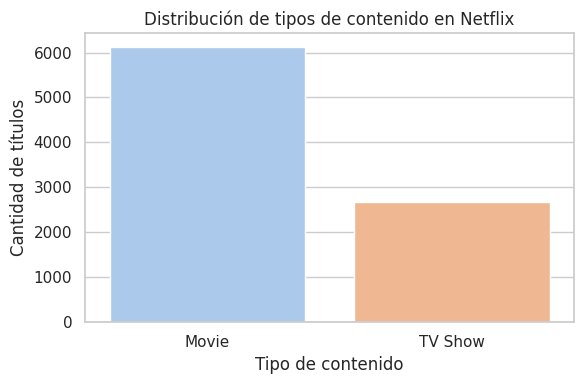

type
Movie      69.615079
TV Show    30.384921
Name: proportion, dtype: float64


In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(
    data=df, x='type', hue='type',
    order=df['type'].value_counts().index,
    palette='pastel', ax=ax, legend=False
)
ax.set_title('Distribución de tipos de contenido en Netflix')
ax.set_xlabel('Tipo de contenido')
ax.set_ylabel('Cantidad de títulos')
plt.tight_layout()
plt.show()

print(df['type'].value_counts(normalize=True) * 100)

**¿Cuál es el tipo de contenido predominante en Netflix? ¿Qué implicancias podría tener para los usuarios?**

El catalogo de Netflix esta dominado por peliculas (Movie), que representan cerca del 70% del total frente a un 30% de series (TV Show). Esto sugiere que la plataforma sigue priorizando el contenido de formato corto y autoconclusivo, aunque las series generan mas "engagement" recurrente (varias sesiones de visualizacion), por lo que seria esperable que Netflix continue invirtiendo en producir series originales.

2. Histograma de años de lanzamiento

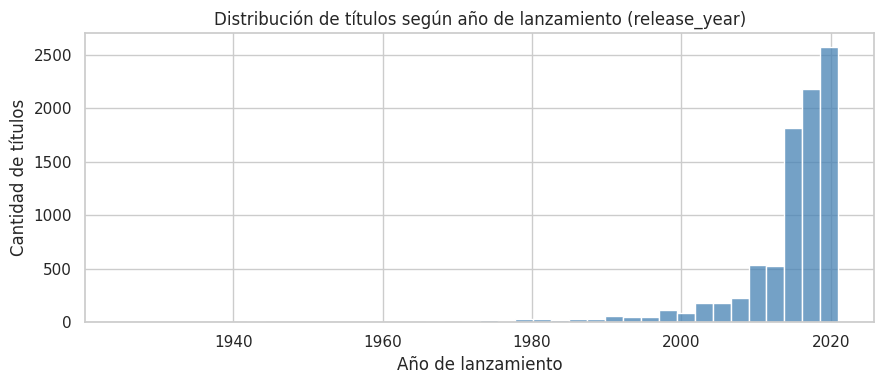

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(data=df, x='release_year', bins=40, color='steelblue', ax=ax)
ax.set_title('Distribución de títulos según año de lanzamiento (release_year)')
ax.set_xlabel('Año de lanzamiento')
ax.set_ylabel('Cantidad de títulos')
plt.tight_layout()
plt.show()

**¿Hay más contenido reciente o antiguo? ¿Notas algún patrón en décadas específicas?**

La gran mayoria del contenido fue lanzado en la ultima decada (2010-2021), con un crecimiento muy marcado a partir de 2015-2016. Esto refleja tanto el auge de las producciones originales de Netflix como su estrategia de licenciar contenido reciente por sobre clasicos antiguos.

3. Proporción de clasificaciones por edad.

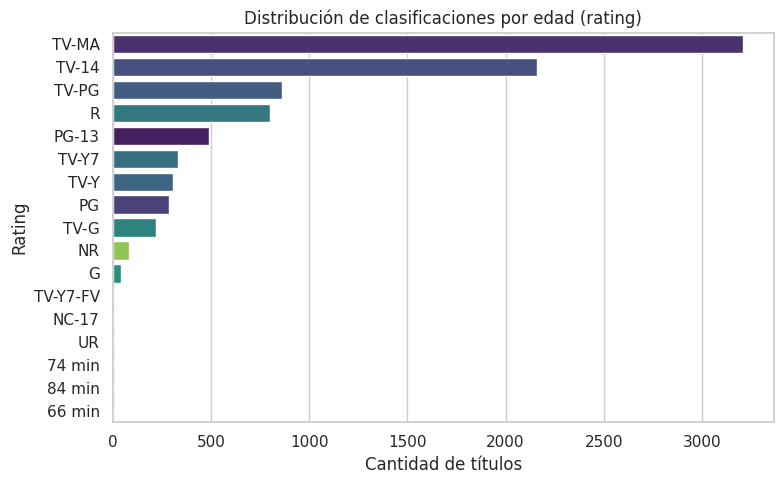

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
order = df['rating'].value_counts().index
sns.countplot(
    data=df, y='rating', hue='rating',
    order=order, palette='viridis', ax=ax, legend=False
)
ax.set_title('Distribución de clasificaciones por edad (rating)')
ax.set_xlabel('Cantidad de títulos')
ax.set_ylabel('Rating')
plt.tight_layout()
plt.show()

**¿Qué clasificación es más común? ¿Crees que Netflix está más enfocado en público adulto, familiar o infantil?**

La categoria mas comun es TV-MA (contenido para audiencia adulta), seguida de TV-14. Esto indica que Netflix enfoca gran parte de su catalogo en publico adulto/joven-adulto, aunque tambien mantiene una porcion relevante de contenido familiar e infantil (TV-Y, TV-Y7, TV-G, PG)

**Parte 2. Tendencias y evolución en el tiempo.**

4. Número de títulos agregados por año

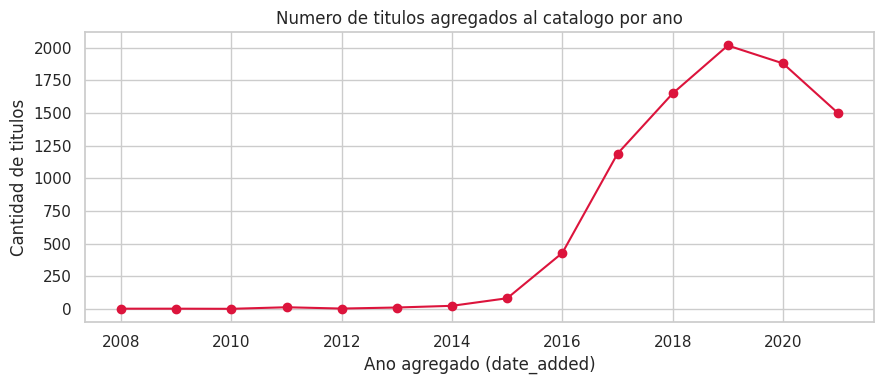

In [6]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

titles_per_year = df.dropna(subset=['year_added']).groupby('year_added').size()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(titles_per_year.index, titles_per_year.values, marker='o', color='crimson')
ax.set_title('Numero de titulos agregados al catalogo por ano')
ax.set_xlabel('Ano agregado (date_added)')
ax.set_ylabel('Cantidad de titulos')
plt.tight_layout()
plt.show()

**¿Cuándo creció más el catálogo de Netflix? ¿Qué relación podría tener con la expansión internacional de la plataforma?**

El catalogo crecio de forma explosiva entre 2016 y 2019, alcanzando su punto mas alto alrededor de 2019, y luego se observa una leve caida en 2020-2021 (posiblemente asociada a la pandemia, que ralentizo producciones y adquisiciones). Este crecimiento coincide con la fuerte expansion internacional de Netflix a partir de 2016, cuando la plataforma llego a practicamente todo el mundo.



**5. Heatmap de lanzamientos por año y mes**

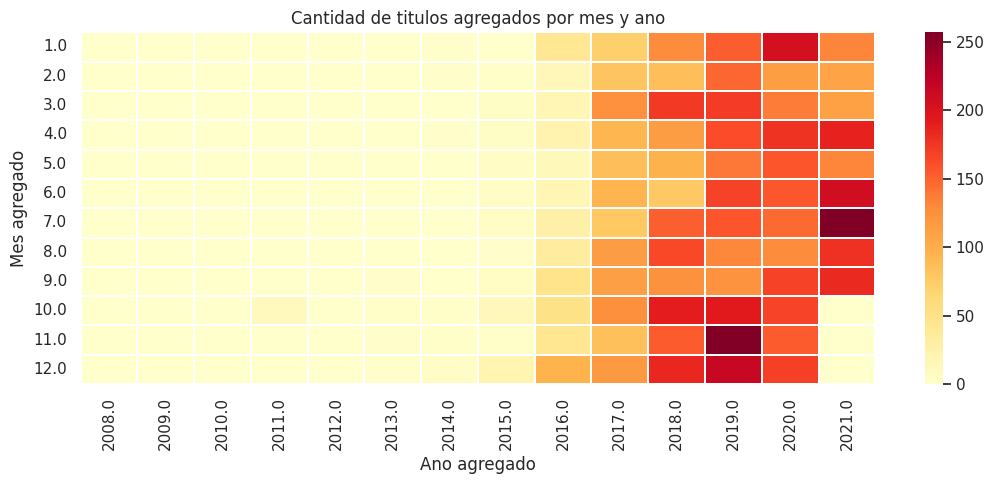

In [7]:
heat_data = (
    df.dropna(subset=['year_added', 'month_added'])
      .pivot_table(index='month_added', columns='year_added',
                   values='show_id', aggfunc='count', fill_value=0)
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(heat_data, cmap='YlOrRd', linewidths=0.3, ax=ax)
ax.set_title('Cantidad de titulos agregados por mes y ano')
ax.set_xlabel('Ano agregado')
ax.set_ylabel('Mes agregado')
plt.tight_layout()
plt.show()

**¿Hay meses con más estrenos que otros? ¿Qué conclusiones puedes sacar sobre la estacionalidad de lanzamientos?**

Se observa que, en los anos de mayor actividad, los meses de fin de ano (octubre-diciembre) y mitad de ano concentran mas estrenos, posiblemente por la busqueda de coincidir con vacaciones y temporadas de mayor consumo. La estacionalidad es mas visible en los anos de mayor volumen de contenido (2018-2020).

**6. Duración de películas por género**

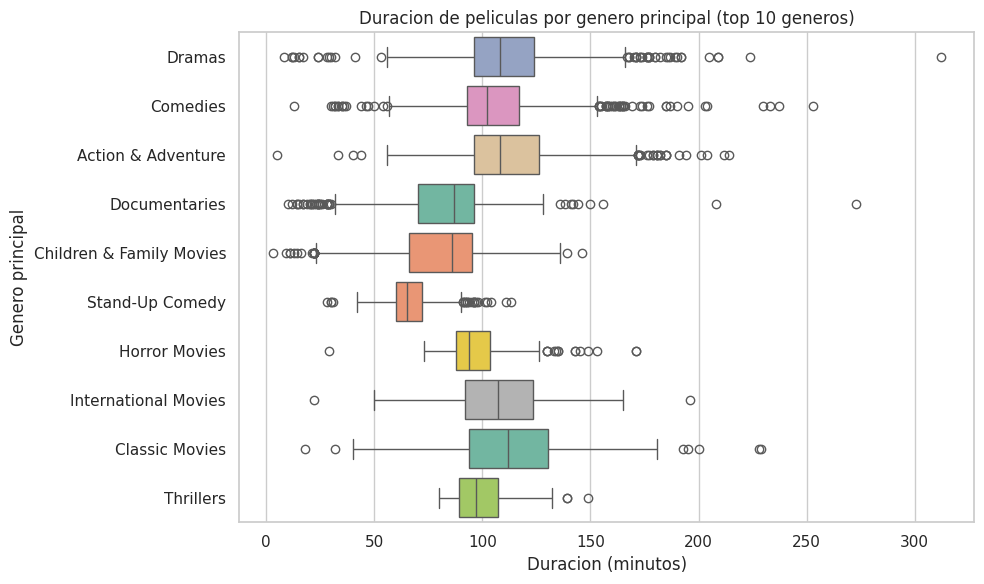

In [8]:
movies = df[df['type'] == 'Movie'].copy()
movies['duration_min'] = movies['duration'].str.extract(r'(\d+)').astype(float)
movies['main_genre'] = movies['listed_in'].str.split(',').str[0].str.strip()

top_genres = movies['main_genre'].value_counts().head(10).index
sub = movies[movies['main_genre'].isin(top_genres)]

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=sub, x='duration_min', y='main_genre', hue='main_genre',
    order=top_genres, palette='Set2', ax=ax, legend=False
)
ax.set_title('Duracion de peliculas por genero principal (top 10 generos)')
ax.set_xlabel('Duracion (minutos)')
ax.set_ylabel('Genero principal')
plt.tight_layout()
plt.show()

**¿Qué géneros suelen durar más? ¿Qué podrías decir sobre la variabilidad dentro de un mismo género?**

Géneros como Dramas o Documentaries tienden a mostrar duraciones mas largas y con mayor dispersion, mientras que generos como Children & Family Movies concentran duraciones mas cortas y homogeneas. La variabilidad dentro de un mismo genero suele ser considerable, lo que indica que la duracion no esta fuertemente estandarizada incluso dentro de una misma categoria.

**Parte 3. Comparaciones y relaciones**

**7. Top 10 países con más producciones.**

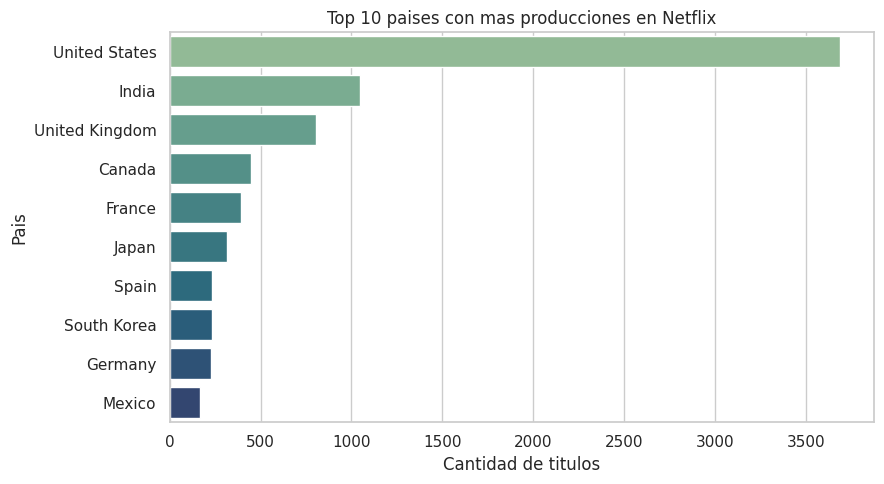

In [9]:
countries = df['country'].dropna().str.split(',').explode().str.strip()
top_countries = countries.value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    x=top_countries.values, y=top_countries.index, hue=top_countries.index,
    palette='crest', ax=ax, legend=False
)
ax.set_title('Top 10 paises con mas producciones en Netflix')
ax.set_xlabel('Cantidad de titulos')
ax.set_ylabel('Pais')
plt.tight_layout()
plt.show()

**¿Qué países dominan el catálogo? ¿Sorprende la distribución o es esperada?**

Estados Unidos domina claramente el catalogo, seguido por India y Reino Unido. Esta distribucion no es del todo sorprendente, ya que Netflix nacio en Estados Unidos y ademas India tiene una industria audiovisual (Bollywood y regional) enorme; sin embargo, confirma que el catalogo aun esta muy concentrado en pocos paises pese al discurso de "contenido global".

**8. Películas vs Series según género**

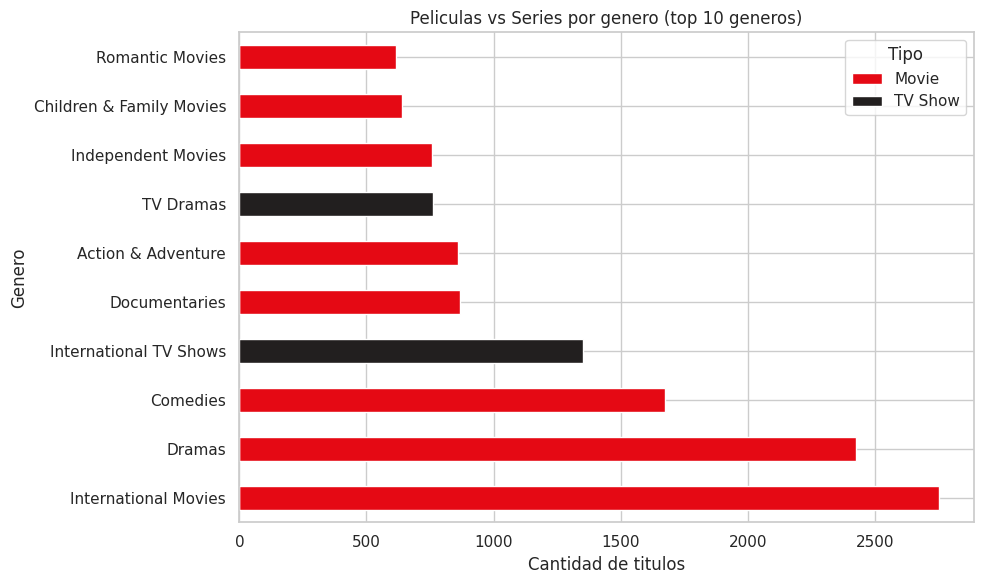

In [10]:
genres = df[['type', 'listed_in']].copy()
genres['genre'] = genres['listed_in'].str.split(',')
genres = genres.explode('genre')
genres['genre'] = genres['genre'].str.strip()

top_genres_list = genres['genre'].value_counts().head(10).index
genres_top = genres[genres['genre'].isin(top_genres_list)]

pivot = (
    genres_top.pivot_table(index='genre', columns='type', values='listed_in',
                            aggfunc='count', fill_value=0)
              .loc[top_genres_list]
)

fig, ax = plt.subplots(figsize=(10, 6))
pivot.plot(kind='barh', stacked=True, ax=ax, color=['#e50914', '#221f1f'])
ax.set_title('Peliculas vs Series por genero (top 10 generos)')
ax.set_xlabel('Cantidad de titulos')
ax.set_ylabel('Genero')
ax.legend(title='Tipo')
plt.tight_layout()
plt.show()

**¿Existen géneros más asociados a películas o a series?**

 Géneros como Dramas, Comedies e International Movies estan mas asociados a peliculas, mientras que TV Dramas, Kids' TV e International TV Shows son predominantemente series. Esto sugiere que Netflix segmenta su produccion segun el tipo de narrativa: historias autoconclusivas en pelicula versus tramas extendidas en formato serie.

**9. Relación entre duración y año de lanzamiento**

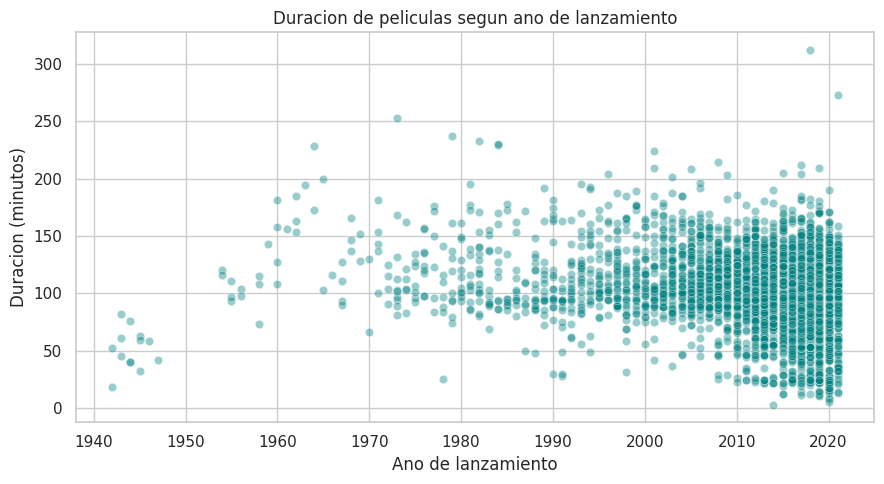

In [11]:
movies = df[df['type'] == 'Movie'].copy()
movies['duration_min'] = movies['duration'].str.extract(r'(\d+)').astype(float)

fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(
    data=movies, x='release_year', y='duration_min',
    alpha=0.4, color='teal', ax=ax
)
ax.set_title('Duracion de peliculas segun ano de lanzamiento')
ax.set_xlabel('Ano de lanzamiento')
ax.set_ylabel('Duracion (minutos)')
plt.tight_layout()
plt.show()

**¿Han cambiado los estándares de duración de las películas con el tiempo? ¿Se ven outliers interesantes?**

Se observa una leve tendencia a la baja en la duracion promedio de las peliculas mas recientes en comparacion con decadas pasadas, aunque la dispersion es alta en todos los periodos. Tambien se aprecian outliers de peliculas muy cortas (posiblemente especiales o documentales breves) y algunas muy largas en anos especificos.

**Desafío Final**

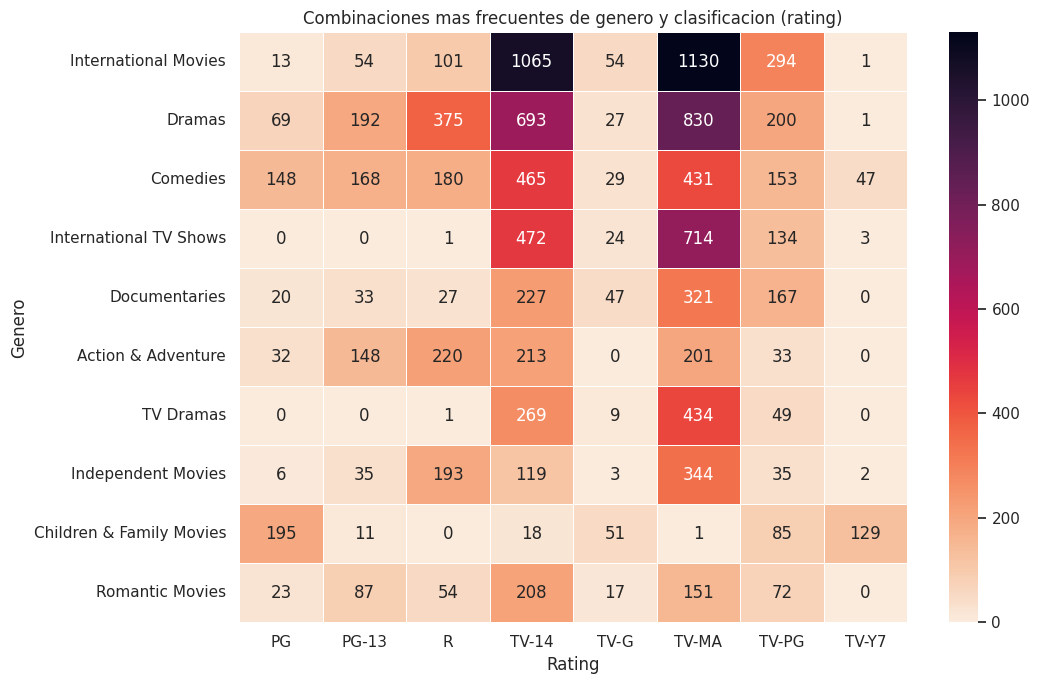

In [12]:
data = df[['listed_in', 'rating']].dropna().copy()
data['genre'] = data['listed_in'].str.split(',')
data = data.explode('genre')
data['genre'] = data['genre'].str.strip()

top_genres = data['genre'].value_counts().head(10).index
main_ratings = data['rating'].value_counts().head(8).index
sub = data[data['genre'].isin(top_genres) & data['rating'].isin(main_ratings)]

combo = (
    sub.pivot_table(index='genre', columns='rating', values='listed_in',
                     aggfunc='count', fill_value=0)
       .loc[top_genres]
)

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(combo, cmap='rocket_r', annot=True, fmt='d', linewidths=0.4, ax=ax)
ax.set_title('Combinaciones mas frecuentes de genero y clasificacion (rating)')
ax.set_xlabel('Rating')
ax.set_ylabel('Genero')
plt.tight_layout()
plt.show()

**¿Qué géneros están más dirigidos a un público adulto? ¿Y cuáles a público familiar o infantil?**

El heatmap muestra que los generos International Movies, Dramas e International TV Shows concentran su mayor volumen en la clasificacion TV-MA, es decir, estan claramente orientados a un publico adulto. En contraste, el genero Children & Family Movies concentra casi la totalidad de sus titulos en clasificaciones familiares e infantiles (PG, TV-Y, TV-Y7, TV-G), lo que confirma una segmentacion bastante clara del catalogo segun genero y publico objetivo. Generos como Comedies muestran una distribucion mas equilibrada entre distintas clasificaciones, lo que sugiere que es un genero mas transversal, con oferta tanto para audiencias adultas como familiares.